In [ ]:
import pandas as pd
import re
import numpy as np
import scanpy as sc
from datetime import datetime
import matplotlib.pyplot as plt
import decoupler as dc
import os
os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()


def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [ ]:
# SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]


In [2]:
OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas"
OUT_H5AD = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/08_TICAannot_on_GBmap/subsets"
os.makedirs(OUT_H5AD, exist_ok=True)

#### color settings and helper functions

In [6]:
from matplotlib.colors import to_hex
import itertools
from fractions import Fraction
import colorsys
import matplotlib.pyplot as plt

In [7]:
# ── Helper functions ─────────────────────────────────────────────────────────────────────
def fracs():
    """Generate fractions for distinct hues."""
    yield Fraction(0)
    for k in range(20):
        denom = 2**k
        for j in range(1, denom, 2):
            yield Fraction(j, denom)

def hsv_to_rgb(x):
    """Convert HSV to RGB."""
    return colorsys.hsv_to_rgb(*map(float, x))


def rgbs():
    """Generate visually distinct RGB colors."""
    for h in fracs():
        for s in [Fraction(6, 10)]:
            for v in [Fraction(8, 10), Fraction(5, 10)]:
                yield hsv_to_rgb((h, s, v))


### all immune cells

In [3]:
adata =  sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")

In [26]:
print(adata)

AnnData object with n_obs × n_vars = 633710 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference

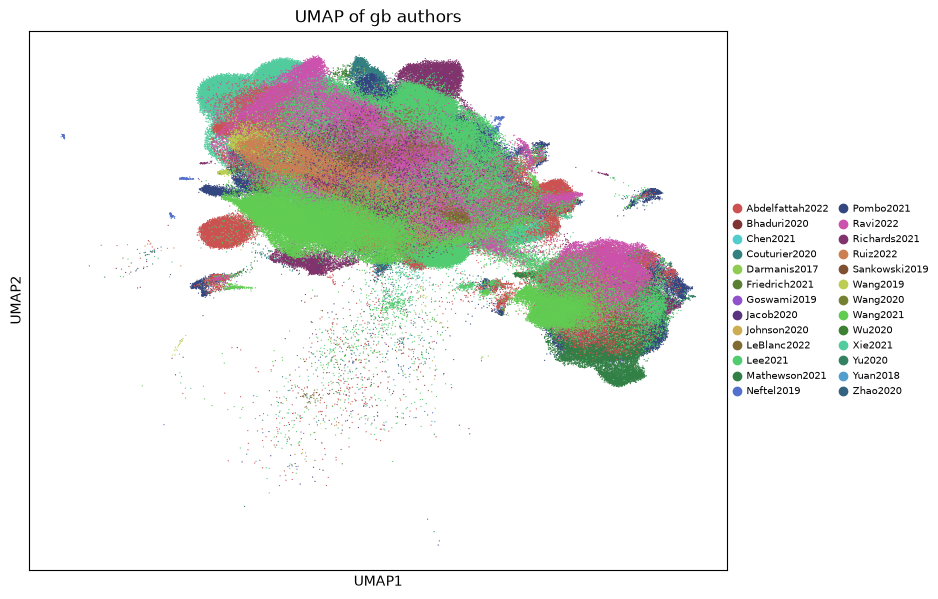

[2026-09-09 11:05:30] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_08_gbmap_authors.pdf


In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

# Generate 25 visually distinct colors
n_categories = 26
colors = list(itertools.islice(rgbs(), n_categories))
palette = [to_hex(c) for c in colors]

sc.pl.umap(adata, color="author", palette=palette, ax=ax, show=False, size=3, legend_fontsize=7, title="UMAP of gb authors")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "08_08_gbmap_authors.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

### CD4/CD8 

In [9]:
TICA_ANNOT_H5AD = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad"
CD4CD8_H5AD = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_subsets/CD4_CD8.h5ad"  


In [10]:
checkpoint("Loading Level1 annotation from full TICA-annotated adata (obs only, backed mode)")
adata_full_obs = sc.read_h5ad(TICA_ANNOT_H5AD, backed="r").obs[
    ["decoupler_level1_celltype", "decoupler_level1_score"]
].copy()
checkpoint(f"Full annotation table: {adata_full_obs.shape[0]} cells")


checkpoint("Loading CD4/CD8 subset (with newly computed NMF/UMAP)")
adata_cd4cd8 = sc.read_h5ad(CD4CD8_H5AD)
checkpoint(f"CD4/CD8 subset loaded: {adata_cd4cd8.n_obs} cells")

[2026-09-09 11:05:30] Loading Level1 annotation from full TICA-annotated adata (obs only, backed mode)
[2026-09-09 11:05:39] Full annotation table: 633710 cells
[2026-09-09 11:05:39] Loading CD4/CD8 subset (with newly computed NMF/UMAP)
[2026-09-09 11:05:45] CD4/CD8 subset loaded: 101945 cells


In [11]:
adata_cd4cd8 = sc.read_h5ad(f"{OUT_H5AD}/cd4_cd8_gb_kc_umap.h5ad")

In [ ]:
import kaleidocell

# kaleidocell.recompute_pca_umap(adata_cd4cd8, n_pcs=50, umap_min_dist=0.5, umap_spread=1.0, random_state=442)
print(adata_cd4cd8)

PCA recomputed.
UMAP recomputed.
AnnData object with n_obs × n_vars = 101945 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'X_approximat

In [12]:
common_cells = adata_full_obs.index.intersection(adata_cd4cd8.obs_names)
n_dropped_full = len(adata_full_obs) - len(common_cells)
n_dropped_subset = adata_cd4cd8.n_obs - len(common_cells)
checkpoint(
    f"Common cells: {len(common_cells)} "
    f"(dropping {n_dropped_full} full-annotation-only cells, {n_dropped_subset} subset-only cells)"
)

if len(common_cells) == 0:
    raise ValueError(
        "No overlapping barcodes between full TICA-annotated adata and CD4/CD8 subset — "
        "inspect both obs_names formats directly, e.g.:\n"
        f"  full:   {list(adata_full_obs.index[:5])}\n"
        f"  subset: {list(adata_cd4cd8.obs_names[:5])}"
    )

if n_dropped_subset > 0:
    checkpoint(
        f"WARNING: {n_dropped_subset} cells in the CD4/CD8 subset have no Level2 annotation "
        "and will be dropped before plotting."
    )


[2026-09-09 11:06:44] Common cells: 101945 (dropping 531765 full-annotation-only cells, 0 subset-only cells)


In [13]:
adata_cd4cd8 = adata_cd4cd8[adata_cd4cd8.obs_names.isin(common_cells)].copy()
adata_cd4cd8.obs["decoupler_level1_celltype"] = adata_full_obs.loc[
    adata_cd4cd8.obs_names, "decoupler_level1_celltype"
].values
adata_cd4cd8.obs["decoupler_level1_score"] = adata_full_obs.loc[
    adata_cd4cd8.obs_names, "decoupler_level1_score"
].values

checkpoint("Level1 annotation distribution in CD4/CD8 subset:")
print(adata_cd4cd8.obs["decoupler_level1_celltype"].value_counts().to_string())



[2026-09-09 11:06:47] Level1 annotation distribution in CD4/CD8 subset:
decoupler_level1_celltype
CD8 cytotoxic               36902
CD4 recently activated      16300
CD4 effector memory         13684
CD4 naive-memory             7944
TAMs C1QC                    5194
CD8 effector memory          3580
CD4 transitional memory      2835
CD8 pre-exhausted            2638
T helper cells               2284
T cells regulatory           2277
T cells naive                1785
CD8 terminally exhausted     1577
Macrophages SPP1             1477
Macro. and mono. prolif.     1207
NK                            557
T cells proliferative         540
mDC                           377
B cells proliferative         215
Plasma B cells                172
pDC                           116
TAMs proinflammatory           79
cDC                            64
B cells                        63
Monocytes                      52
Mast cells                     26


#### UMAP with TICA level 1 annotation 

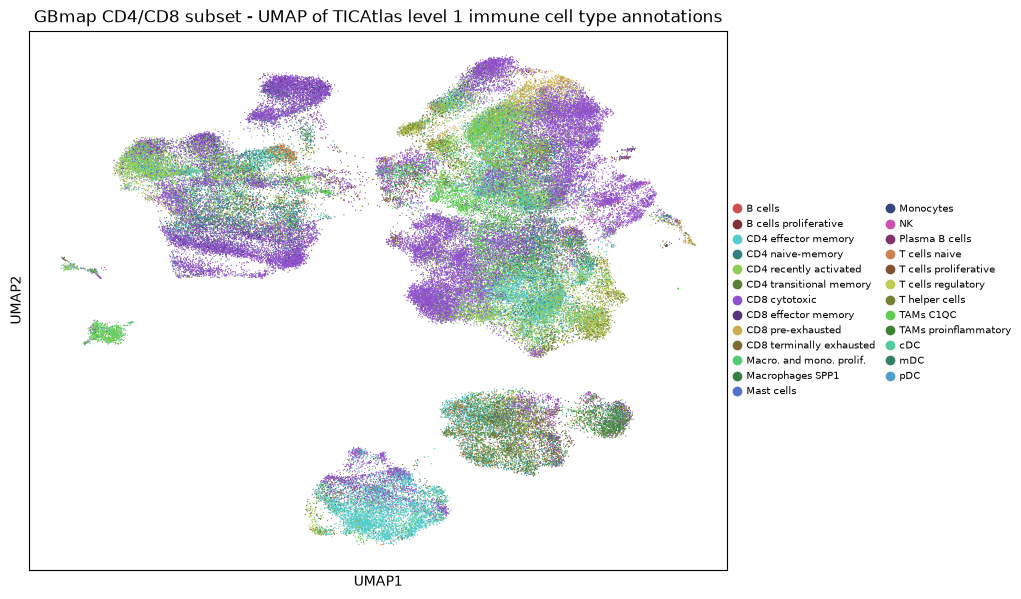

[2026-09-09 11:10:28] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_08_cd4cd8_umap_tica_level1.pdf


In [15]:
fig, ax = plt.subplots(figsize=(9, 7))

# Generate 25 visually distinct colors
n_categories = 25
colors = list(itertools.islice(rgbs(), n_categories))
palette = [to_hex(c) for c in colors]

sc.pl.umap(adata_cd4cd8, color="decoupler_level1_celltype", palette=palette, ax=ax, show=False, size=3, legend_fontsize=7, title="GBmap CD4/CD8 subset - UMAP of TICAtlas level 1 immune cell type annotations")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "08_08_cd4cd8_umap_tica_level1.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

#### UMAP with author annotation

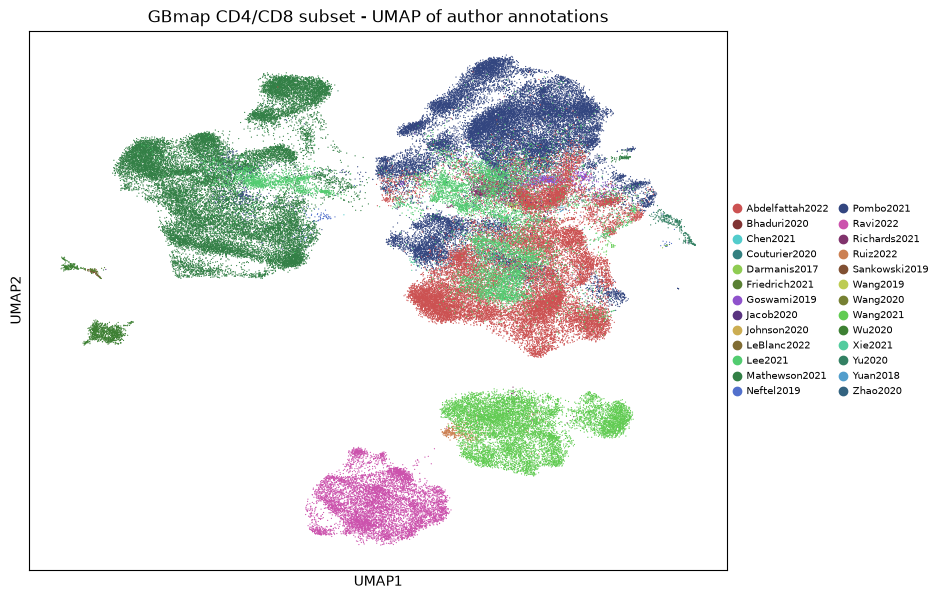

[2026-09-09 11:10:45] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_08_cd4cd8_umap_authors.pdf


In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

# Generate 25 visually distinct colors
n_categories = 26
colors = list(itertools.islice(rgbs(), n_categories))
palette = [to_hex(c) for c in colors]

sc.pl.umap(adata_cd4cd8, color="author", palette=palette, ax=ax, show=False, size=3, legend_fontsize=7, title="GBmap CD4/CD8 subset - UMAP of author annotations")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "08_08_cd4cd8_umap_authors.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

#### Barplot CD4/CD8 level 1 celltype distribution

/tmp/ipykernel_4087107/1842236749.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


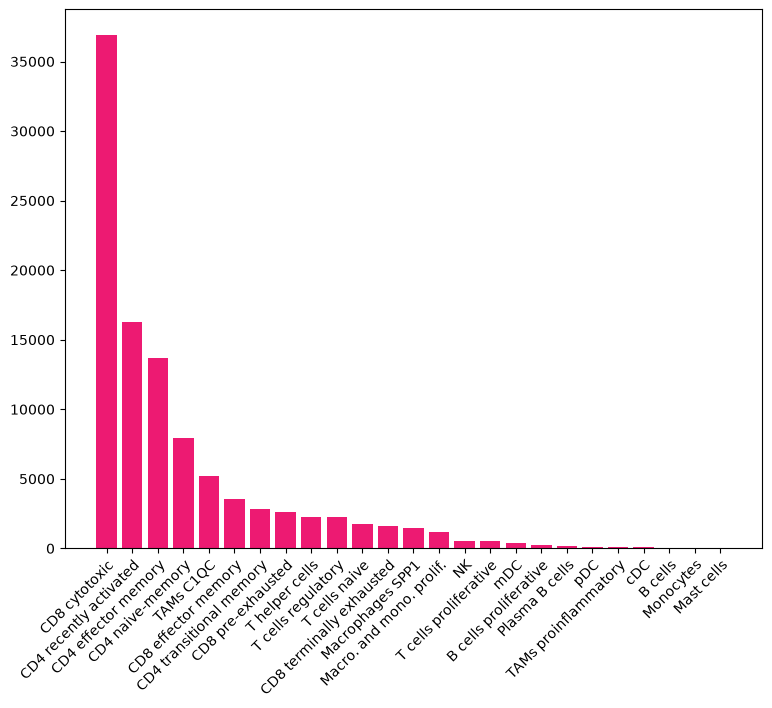

In [25]:
INFERNO_PINK = "#ed1a72"
fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(adata_cd4cd8.obs["decoupler_level1_celltype"].value_counts().index, adata_cd4cd8.obs["decoupler_level1_celltype"].value_counts().values, color=INFERNO_PINK)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.show()


#### Save H5ad file with new UMAP

In [18]:
adata_cd4cd8.write(f"{OUT_H5AD}/cd4_cd8_gb_kc_umap.h5ad")

#### Scanpy Harmony for batch correction on CD4/CD8 subset

In [ ]:
import scanpy.external as sce



#### MP-scores of CD4/CD8 grid

In [22]:
mp_scores_cd = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_4_nmf_subsets_c7/CD4_CD8/mp_scores_CD4_CD8.csv", index_col=0)

In [27]:
checkpoint(f"mp_scores_cd shape: {mp_scores_cd.shape}")
checkpoint(f"First columns: {mp_scores_cd.columns[:10].tolist()}")
checkpoint(f"First index values: {mp_scores_cd.index[:5].tolist()}")

[2026-09-03 10:31:30] mp_scores_cd shape: (100537, 18)
[2026-09-03 10:31:30] First columns: ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score', 'MP10_score']
[2026-09-03 10:31:30] First index values: ['MGH106CD3posP1-A03-0', 'MGH106CD3posP1-A05-0', 'MGH106CD3posP1-A06-0', 'MGH106CD3posP1-A07-0', 'MGH106CD3posP1-A08-0']


In [28]:
mp_cols = sorted(
    [
        col for col in mp_scores_cd.columns
        if re.match(r"^MP\d+_score$", str(col))
    ],
    key=lambda x: int(re.search(r"\d+", x).group())
)

checkpoint(f"MP columns found ({len(mp_cols)}): {mp_cols}")

[2026-09-03 10:32:21] MP columns found (18): ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score', 'MP10_score', 'MP11_score', 'MP12_score', 'MP13_score', 'MP14_score', 'MP15_score', 'MP16_score', 'MP17_score', 'MP18_score']


In [31]:
# important: cell-IDs as strings
mp_scores_cd.index = mp_scores_cd.index.astype(str)
adata_cd4cd8.obs_names = adata_cd4cd8.obs_names.astype(str)

# in exact order of the cells in the CD4/CD8 UMAP
mp_scores_aligned = mp_scores_cd[mp_cols].reindex(adata_cd4cd8.obs_names)

# write scores as new obs columns in the CD4/CD8 AnnData
for mp in mp_cols:
    adata_cd4cd8.obs[mp] = mp_scores_aligned[mp].to_numpy()

checkpoint(f"Added {len(mp_cols)} CD MP scores to adata_cd4cd8.obs")

[2026-09-03 10:35:02] Added 18 CD MP scores to adata_cd4cd8.obs


In [33]:
# Check alignment
n_matched = mp_scores_aligned.notna().any(axis=1).sum()

checkpoint(f"Matched cells: {n_matched}/{adata_cd4cd8.n_obs}")

missing_cells = adata_cd4cd8.obs_names[
    ~adata_cd4cd8.obs_names.isin(mp_scores_cd.index)
]

checkpoint(f"Unmatched cells: {len(missing_cells)}")
checkpoint(f"Examples unmatched: {missing_cells[:10].tolist()}")

for mp in mp_cols:
    checkpoint(
        f"{mp}: "
        f"NaN={adata_cd4cd8.obs[mp].isna().sum()}, "
        f"range={adata_cd4cd8.obs[mp].min():.3f}–{adata_cd4cd8.obs[mp].max():.3f}"
    )

[2026-09-03 10:35:37] Matched cells: 100537/101945
[2026-09-03 10:35:37] Unmatched cells: 1408
[2026-09-03 10:35:37] Examples unmatched: ['PJ017_301-0', 'PJ017_444-0', 'PJ017_450-0', 'PJ017_489-0', 'PJ017_491-0', 'PJ017_503-0', 'PJ017_525-0', 'PJ017_529-0', 'PJ017_543-0', 'PJ017_570-0']
[2026-09-03 10:35:37] MP1_score: NaN=1408, range=-0.216–0.854
[2026-09-03 10:35:37] MP2_score: NaN=1408, range=-0.738–4.915
[2026-09-03 10:35:37] MP3_score: NaN=1408, range=-0.965–2.966
[2026-09-03 10:35:37] MP4_score: NaN=1408, range=-0.343–1.803
[2026-09-03 10:35:37] MP5_score: NaN=1408, range=-0.522–2.297
[2026-09-03 10:35:37] MP6_score: NaN=1408, range=-0.339–2.086
[2026-09-03 10:35:37] MP7_score: NaN=1408, range=-0.246–1.154
[2026-09-03 10:35:37] MP8_score: NaN=1408, range=-0.259–1.701
[2026-09-03 10:35:37] MP9_score: NaN=1408, range=-0.696–3.787
[2026-09-03 10:35:37] MP10_score: NaN=1408, range=0.119–0.592
[2026-09-03 10:35:37] MP11_score: NaN=1408, range=0.026–0.235
[2026-09-03 10:35:37] MP12_sco

[2026-09-03 10:35:37] MP16_score: NaN=1408, range=-0.127–0.818
[2026-09-03 10:35:37] MP17_score: NaN=1408, range=-1.222–5.421
[2026-09-03 10:35:37] MP18_score: NaN=1408, range=-1.090–2.712


In [35]:
missing_cells = adata_cd4cd8.obs_names[
    ~adata_cd4cd8.obs_names.isin(mp_scores_cd.index)
]

checkpoint(f"First unmatched adata IDs: {missing_cells[:20].tolist()}")

# IDs im CSV, die nicht im CD4/CD8-adata vorkommen
csv_only_cells = mp_scores_cd.index[
    ~mp_scores_cd.index.isin(adata_cd4cd8.obs_names)
]

checkpoint(f"CSV-only cells: {len(csv_only_cells)}")
checkpoint(f"First CSV-only IDs: {csv_only_cells[:20].tolist()}")

[2026-09-03 10:37:11] First unmatched adata IDs: ['PJ017_301-0', 'PJ017_444-0', 'PJ017_450-0', 'PJ017_489-0', 'PJ017_491-0', 'PJ017_503-0', 'PJ017_525-0', 'PJ017_529-0', 'PJ017_543-0', 'PJ017_570-0', 'PJ017_579-0', 'PJ017_583-0', 'PJ017_586-0', 'PJ017_678-0', 'PJ017_683-0', 'PJ017_697-0', 'PJ017_706-0', 'PJ017_723-0', 'PJ017_734-0', 'PJ017_740-0']
[2026-09-03 10:37:11] CSV-only cells: 0
[2026-09-03 10:37:11] First CSV-only IDs: []


In [47]:
ALL_MPS = sorted(
    [
        col for col in adata_cd4cd8.obs.columns
        if re.match(r"^MP\d+_score$", str(col))
    ],
    key=lambda x: int(re.search(r"\d+", x).group())
)

checkpoint(f"MP scores to plot ({len(ALL_MPS)}): {ALL_MPS}")

adata_scored = adata_cd4cd8[adata_cd4cd8.obs[ALL_MPS].notna().all(axis=1)].copy()

checkpoint(f"Cells used: {adata_scored.n_obs}/{adata_cd4cd8.n_obs}")

[2026-09-03 10:50:00] MP scores to plot (18): ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score', 'MP10_score', 'MP11_score', 'MP12_score', 'MP13_score', 'MP14_score', 'MP15_score', 'MP16_score', 'MP17_score', 'MP18_score']
[2026-09-03 10:50:01] Cells used: 100537/101945


[2026-09-03 10:58:59] Plotted MP1
[2026-09-03 10:58:59] Plotted MP2
[2026-09-03 10:58:59] Plotted MP3
[2026-09-03 10:58:59] Plotted MP4
[2026-09-03 10:58:59] Plotted MP5
[2026-09-03 10:58:59] Plotted MP6
[2026-09-03 10:58:59] Plotted MP7
[2026-09-03 10:59:00] Plotted MP8
[2026-09-03 10:59:00] Plotted MP9
[2026-09-03 10:59:00] Plotted MP10
[2026-09-03 10:59:00] Plotted MP11
[2026-09-03 10:59:00] Plotted MP12
[2026-09-03 10:59:00] Plotted MP13
[2026-09-03 10:59:00] Plotted MP14
[2026-09-03 10:59:00] Plotted MP15
[2026-09-03 10:59:00] Plotted MP16
[2026-09-03 10:59:00] Plotted MP17
[2026-09-03 10:59:01] Plotted MP18


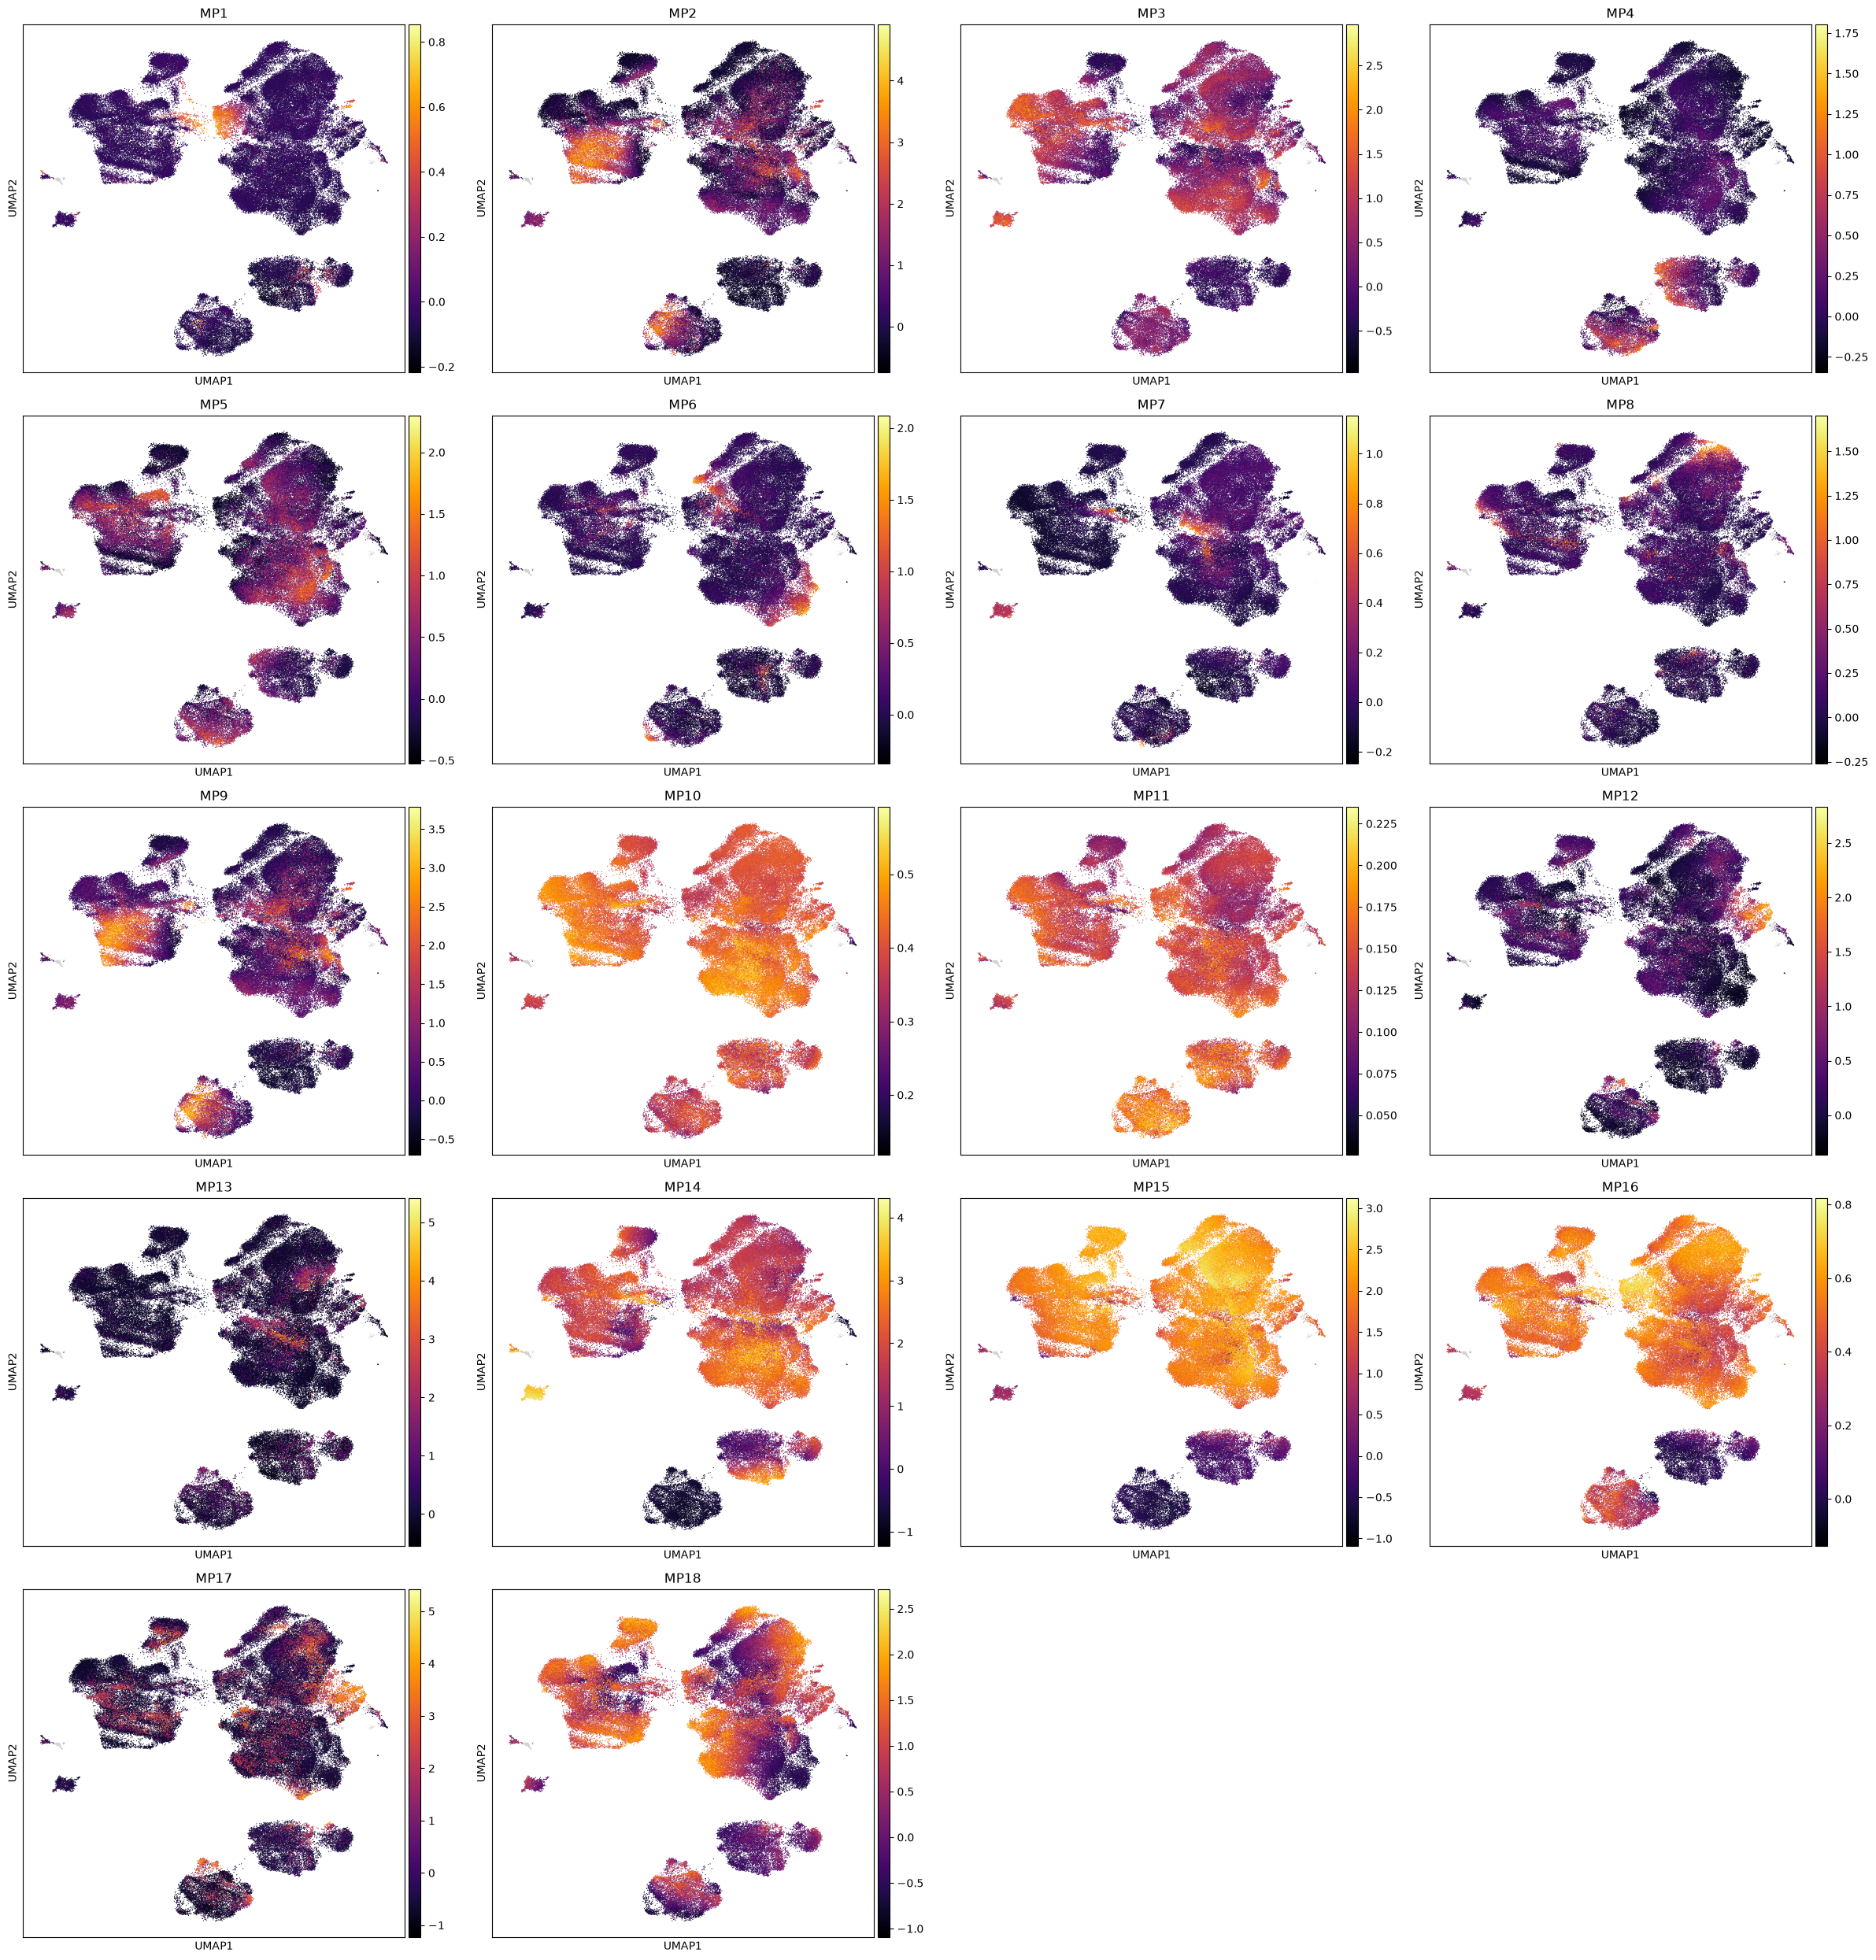

[2026-09-03 10:59:29] PDF saved
[2026-09-03 10:59:29] ALL DONE!


In [53]:
n_cols = 4
n_rows = -(-len(ALL_MPS) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col_name in enumerate(ALL_MPS):
    mp_title = col_name.replace("_score", "")
    if col_name in adata_cd4cd8.obs.columns:
        sc.pl.umap(adata_cd4cd8, color=col_name, color_map="inferno", ax=axes[i], title=mp_title, size=3, frameon=True, show=False)
        axes[i].set_rasterized(True)
        checkpoint(f"Plotted {mp_title}")
    else:
        checkpoint(f"SKIPPED {mp_title} (not in adata_cd4cd8.obs)")

# Hide empty subplots
for j in range(len(ALL_MPS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_08_umap_cd4cd8_mpscores.pdf"), bbox_inches="tight", dpi=200)
plt.show()
plt.close()
checkpoint("PDF saved")

checkpoint("ALL DONE!")

### TAM-MG 

In [7]:
TAM_MG_H5AD = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_subsets/TAM-MG.h5ad"

In [10]:
checkpoint("Loading Level1 annotation from full TICA-annotated adata (obs only, backed mode)")
adata_full_obs = sc.read_h5ad(TICA_ANNOT_H5AD, backed="r").obs[
    ["decoupler_level1_celltype", "decoupler_level1_score"]
].copy()
checkpoint(f"Full annotation table: {adata_full_obs.shape[0]} cells")


checkpoint("Loading TAM-MG subset (with newly computed NMF/UMAP)")
adata_tam_mg = sc.read_h5ad(TAM_MG_H5AD)
checkpoint(f"TAM-MG subset loaded: {adata_tam_mg.n_obs} cells")

[2026-09-08 19:32:02] Loading Level1 annotation from full TICA-annotated adata (obs only, backed mode)
[2026-09-08 19:32:09] Full annotation table: 633710 cells
[2026-09-08 19:32:09] Loading TAM-MG subset (with newly computed NMF/UMAP)
[2026-09-08 19:32:28] TAM-MG subset loaded: 200606 cells


#### calculate UMAP again

In [11]:
import kaleidocell

kaleidocell.recompute_pca_umap(adata_tam_mg, n_pcs=50, umap_min_dist=0.5, umap_spread=1.0, random_state=442)
checkpoint(print(adata_tam_mg))

PCA recomputed.
UMAP recomputed.
AnnData object with n_obs × n_vars = 200606 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'X_approximat

In [58]:
common_cells = adata_full_obs.index.intersection(adata_tam_mg.obs_names)
n_dropped_full = len(adata_full_obs) - len(common_cells)
n_dropped_subset = adata_tam_mg.n_obs - len(common_cells)
checkpoint(
    f"Common cells: {len(common_cells)} "
    f"(dropping {n_dropped_full} full-annotation-only cells, {n_dropped_subset} subset-only cells)"
)

if len(common_cells) == 0:
    raise ValueError(
        "No overlapping barcodes between full TICA-annotated adata and TAM-MG subset — "
        "inspect both obs_names formats directly, e.g.:\n"
        f"  full:   {list(adata_full_obs.index[:5])}\n"
        f"  subset: {list(adata_tam_mg.obs_names[:5])}"
    )

if n_dropped_subset > 0:
    checkpoint(
        f"WARNING: {n_dropped_subset} cells in the TAM-MG subset have no Level2 annotation "
        "and will be dropped before plotting."
    )


[2026-09-03 11:18:21] Common cells: 200606 (dropping 433104 full-annotation-only cells, 0 subset-only cells)


In [59]:
adata_tam_mg = adata_tam_mg[adata_tam_mg.obs_names.isin(common_cells)].copy()
adata_tam_mg.obs["decoupler_level1_celltype"] = adata_full_obs.loc[
    adata_tam_mg.obs_names, "decoupler_level1_celltype"
].values
adata_tam_mg.obs["decoupler_level1_score"] = adata_full_obs.loc[
    adata_tam_mg.obs_names, "decoupler_level1_score"
].values

checkpoint("Level1 annotation distribution in TAM-MG subset:")
print(adata_tam_mg.obs["decoupler_level1_celltype"].value_counts().to_string())



[2026-09-03 11:18:27] Level1 annotation distribution in TAM-MG subset:
decoupler_level1_celltype
TAMs C1QC                   163876
Macro. and mono. prolif.     14398
Macrophages SPP1             11256
mDC                           5790
cDC                           1738
pDC                           1269
Monocytes                      816
TAMs proinflammatory           603
CD8 pre-exhausted              246
CD4 effector memory            192
CD4 recently activated          99
B cells                         58
T cells proliferative           43
CD8 terminally exhausted        40
T cells regulatory              38
B cells proliferative           36
CD4 naive-memory                24
CD4 transitional memory         22
CD8 cytotoxic                   18
T helper cells                  17
Plasma B cells                   8
T cells naive                    6
Mast cells                       6
CD8 effector memory              5
NK                               2


#### color settings and helper functions

In [60]:

from matplotlib.colors import to_hex
import itertools
from fractions import Fraction
import colorsys
import matplotlib.pyplot as plt

# ── Helper functions ─────────────────────────────────────────────────────────────────────
def fracs():
    """Generate fractions for distinct hues."""
    yield Fraction(0)
    for k in range(20):
        denom = 2**k
        for j in range(1, denom, 2):
            yield Fraction(j, denom)

def hsv_to_rgb(x):
    """Convert HSV to RGB."""
    return colorsys.hsv_to_rgb(*map(float, x))

def rgbs():
    """Generate visually distinct RGB colors."""
    for h in fracs():
        for s in [Fraction(6, 10)]:
            for v in [Fraction(8, 10), Fraction(5, 10)]:
                yield hsv_to_rgb((h, s, v))


#### UMAP with TICA level 1 annotation 

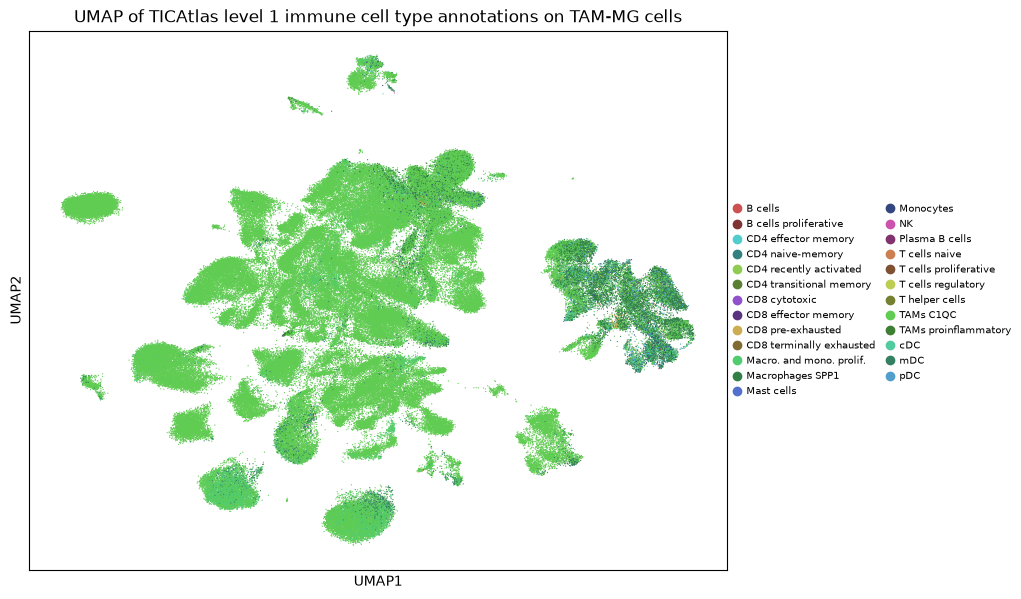

[2026-09-03 12:57:49] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/08_TICAtlas/08_08_tam_mg_umap_tica_level1.pdf


In [61]:
fig, ax = plt.subplots(figsize=(9, 7))

# Generate 25 visually distinct colors
n_categories = 25
colors = list(itertools.islice(rgbs(), n_categories))
palette = [to_hex(c) for c in colors]

sc.pl.umap(adata_tam_mg, color="decoupler_level1_celltype", palette=palette, ax=ax, show=False, size=3, legend_fontsize=7, title="UMAP of TICAtlas level 1 immune cell type annotations on TAM-MG cells")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "08_08_tam_mg_umap_tica_level1.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

In [ ]:
adata_tam_mg.write(f"{OUT_H5AD}/tam_mg_gb_kc_umap.h5ad")

#### UMAP with author annotation

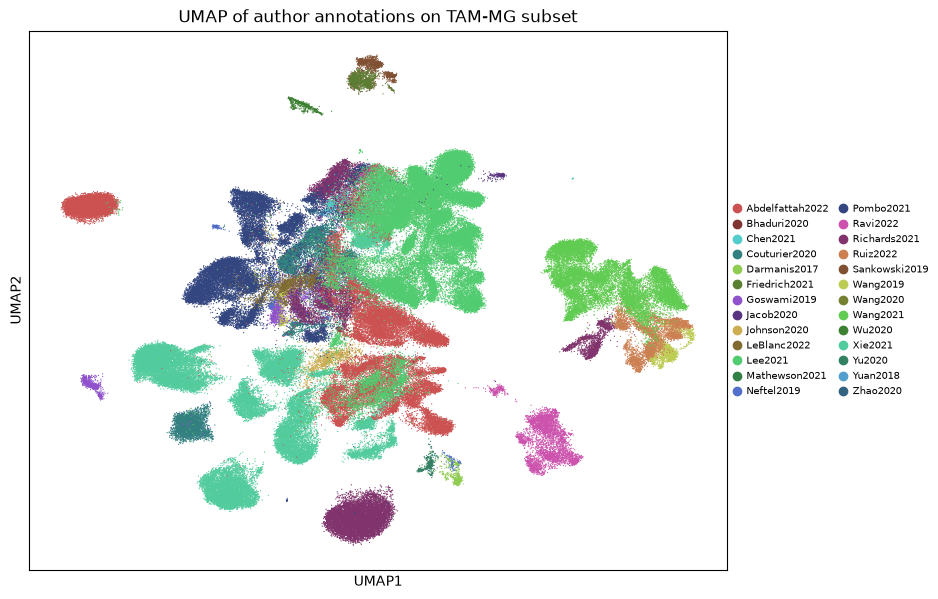

In [65]:
fig, ax = plt.subplots(figsize=(9, 7))

# Generate 25 visually distinct colors
n_categories = 26
colors = list(itertools.islice(rgbs(), n_categories))
palette = [to_hex(c) for c in colors]

sc.pl.umap(adata_tam_mg, color="author", palette=palette, ax=ax, show=False, size=3, legend_fontsize=7, title="UMAP of author annotations on TAM-MG subset")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "08_08_tam_mg_umap_authors.pdf")
# plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
# checkpoint(f"UMAP saved: {out_umap}")

#### Barplot TAM-MG level 1 celltype distribution

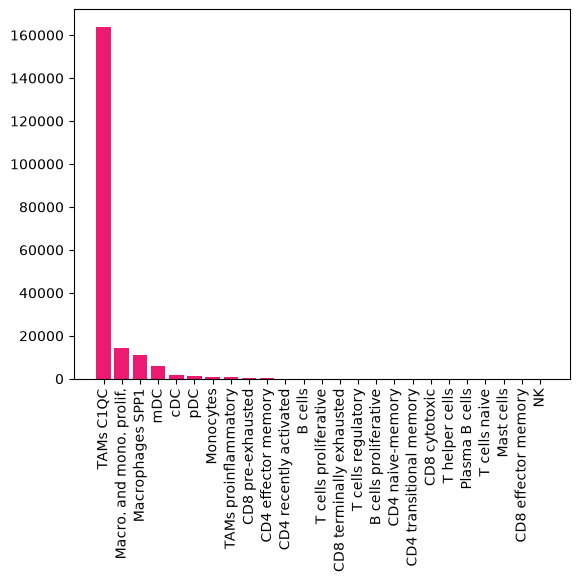

In [67]:
INFERNO_PINK = "#ed1a72"
plt.bar(adata_tam_mg.obs["decoupler_level1_celltype"].value_counts().index, adata_tam_mg.obs["decoupler_level1_celltype"].value_counts().values, color=INFERNO_PINK)
plt.xticks(rotation=90)
plt.show()


#### MP-scores of TAM-MG grid

In [70]:
mp_scores_tam_mg = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_4_nmf_subsets_c7/TAM-MG/mp_scores_TAM-MG.csv", index_col=0)

In [71]:
checkpoint(f"mp_scores_tam_mg shape: {mp_scores_tam_mg.shape}")
checkpoint(f"First columns: {mp_scores_tam_mg.columns[:10].tolist()}")
checkpoint(f"First index values: {mp_scores_tam_mg.index[:5].tolist()}")

[2026-09-03 13:03:36] mp_scores_tam_mg shape: (199741, 9)
[2026-09-03 13:03:36] First columns: ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score']
[2026-09-03 13:03:36] First index values: ['PJ017_34-0', 'PJ017_87-0', 'PJ017_90-0', 'PJ017_111-0', 'PJ017_142-0']


In [72]:
mp_cols = sorted(
    [
        col for col in mp_scores_tam_mg.columns
        if re.match(r"^MP\d+_score$", str(col))
    ],
    key=lambda x: int(re.search(r"\d+", x).group())
)

checkpoint(f"MP columns found ({len(mp_cols)}): {mp_cols}")

[2026-09-03 15:46:14] MP columns found (9): ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score']


In [73]:
# important: cell-IDs as strings
mp_scores_tam_mg.index = mp_scores_tam_mg.index.astype(str)
adata_tam_mg.obs_names = adata_tam_mg.obs_names.astype(str)

# in exact order of the cells in the CD4/CD8 UMAP
mp_scores_aligned = mp_scores_tam_mg[mp_cols].reindex(adata_tam_mg.obs_names)

# write scores as new obs columns in the CD4/CD8 AnnData
for mp in mp_cols:
    adata_tam_mg.obs[mp] = mp_scores_aligned[mp].to_numpy()

checkpoint(f"Added {len(mp_cols)} CD MP scores to adata_tam_mg.obs")

[2026-09-03 15:47:04] Added 9 CD MP scores to adata_tam_mg.obs


In [74]:
# Check alignment
n_matched = mp_scores_aligned.notna().any(axis=1).sum()

checkpoint(f"Matched cells: {n_matched}/{adata_tam_mg.n_obs}")

missing_cells = adata_tam_mg.obs_names[
    ~adata_tam_mg.obs_names.isin(mp_scores_tam_mg.index)
]

checkpoint(f"Unmatched cells: {len(missing_cells)}")
checkpoint(f"Examples unmatched: {missing_cells[:10].tolist()}")

for mp in mp_cols:
    checkpoint(
        f"{mp}: "
        f"NaN={adata_tam_mg.obs[mp].isna().sum()}, "
        f"range={adata_tam_mg.obs[mp].min():.3f}–{adata_tam_mg.obs[mp].max():.3f}"
    )

[2026-09-03 15:47:32] Matched cells: 199741/200606
[2026-09-03 15:47:32] Unmatched cells: 865
[2026-09-03 15:47:32] Examples unmatched: ['PJ018_90-0', 'PJ018_428-0', 'PJ018_702-0', 'PJ018_806-0', 'PJ018_835-0', 'PJ018_909-0', 'PJ018_1152-0', 'PJ018_1309-0', 'PJ018_1344-0', 'PJ018_1403-0']
[2026-09-03 15:47:32] MP1_score: NaN=865, range=-0.734–4.039
[2026-09-03 15:47:32] MP2_score: NaN=865, range=-0.515–2.258
[2026-09-03 15:47:32] MP3_score: NaN=865, range=-1.082–4.825
[2026-09-03 15:47:32] MP4_score: NaN=865, range=-0.234–0.912
[2026-09-03 15:47:32] MP5_score: NaN=865, range=-0.698–4.372
[2026-09-03 15:47:32] MP6_score: NaN=865, range=-0.358–2.464
[2026-09-03 15:47:32] MP7_score: NaN=865, range=0.000–0.250
[2026-09-03 15:47:32] MP8_score: NaN=865, range=-0.141–1.103
[2026-09-03 15:47:32] MP9_score: NaN=865, range=-0.166–2.063


In [75]:
missing_cells = adata_tam_mg.obs_names[
    ~adata_tam_mg.obs_names.isin(mp_scores_tam_mg.index)
]

checkpoint(f"First unmatched adata IDs: {missing_cells[:20].tolist()}")

# IDs im CSV, die nicht im TAM-MG-adata vorkommen
csv_only_cells = mp_scores_tam_mg.index[
    ~mp_scores_tam_mg.index.isin(adata_tam_mg.obs_names)
]

checkpoint(f"CSV-only cells: {len(csv_only_cells)}")
checkpoint(f"First CSV-only IDs: {csv_only_cells[:20].tolist()}")

[2026-09-03 15:47:59] First unmatched adata IDs: ['PJ018_90-0', 'PJ018_428-0', 'PJ018_702-0', 'PJ018_806-0', 'PJ018_835-0', 'PJ018_909-0', 'PJ018_1152-0', 'PJ018_1309-0', 'PJ018_1344-0', 'PJ018_1403-0', 'PJ018_1439-0', 'PJ018_1468-0', 'PJ018_1481-0', 'PJ018_1538-0', 'PJ018_1651-0', 'PJ018_1681-0', 'PJ018_1687-0', 'PJ018_1759-0', 'PJ018_1894-0', 'PJ018_1939-0']
[2026-09-03 15:47:59] CSV-only cells: 0
[2026-09-03 15:47:59] First CSV-only IDs: []


In [76]:
ALL_MPS = sorted(
    [
        col for col in adata_tam_mg.obs.columns
        if re.match(r"^MP\d+_score$", str(col))
    ],
    key=lambda x: int(re.search(r"\d+", x).group())
)

checkpoint(f"MP scores to plot ({len(ALL_MPS)}): {ALL_MPS}")

adata_scored = adata_tam_mg[adata_tam_mg.obs[ALL_MPS].notna().all(axis=1)].copy()

checkpoint(f"Cells used: {adata_scored.n_obs}/{adata_tam_mg.n_obs}")

[2026-09-03 15:48:16] MP scores to plot (9): ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score']
[2026-09-03 15:48:17] Cells used: 199741/200606


[2026-09-03 15:48:40] Plotted MP1
[2026-09-03 15:48:41] Plotted MP2
[2026-09-03 15:48:41] Plotted MP3
[2026-09-03 15:48:41] Plotted MP4
[2026-09-03 15:48:41] Plotted MP5
[2026-09-03 15:48:41] Plotted MP6
[2026-09-03 15:48:42] Plotted MP7
[2026-09-03 15:48:42] Plotted MP8
[2026-09-03 15:48:42] Plotted MP9


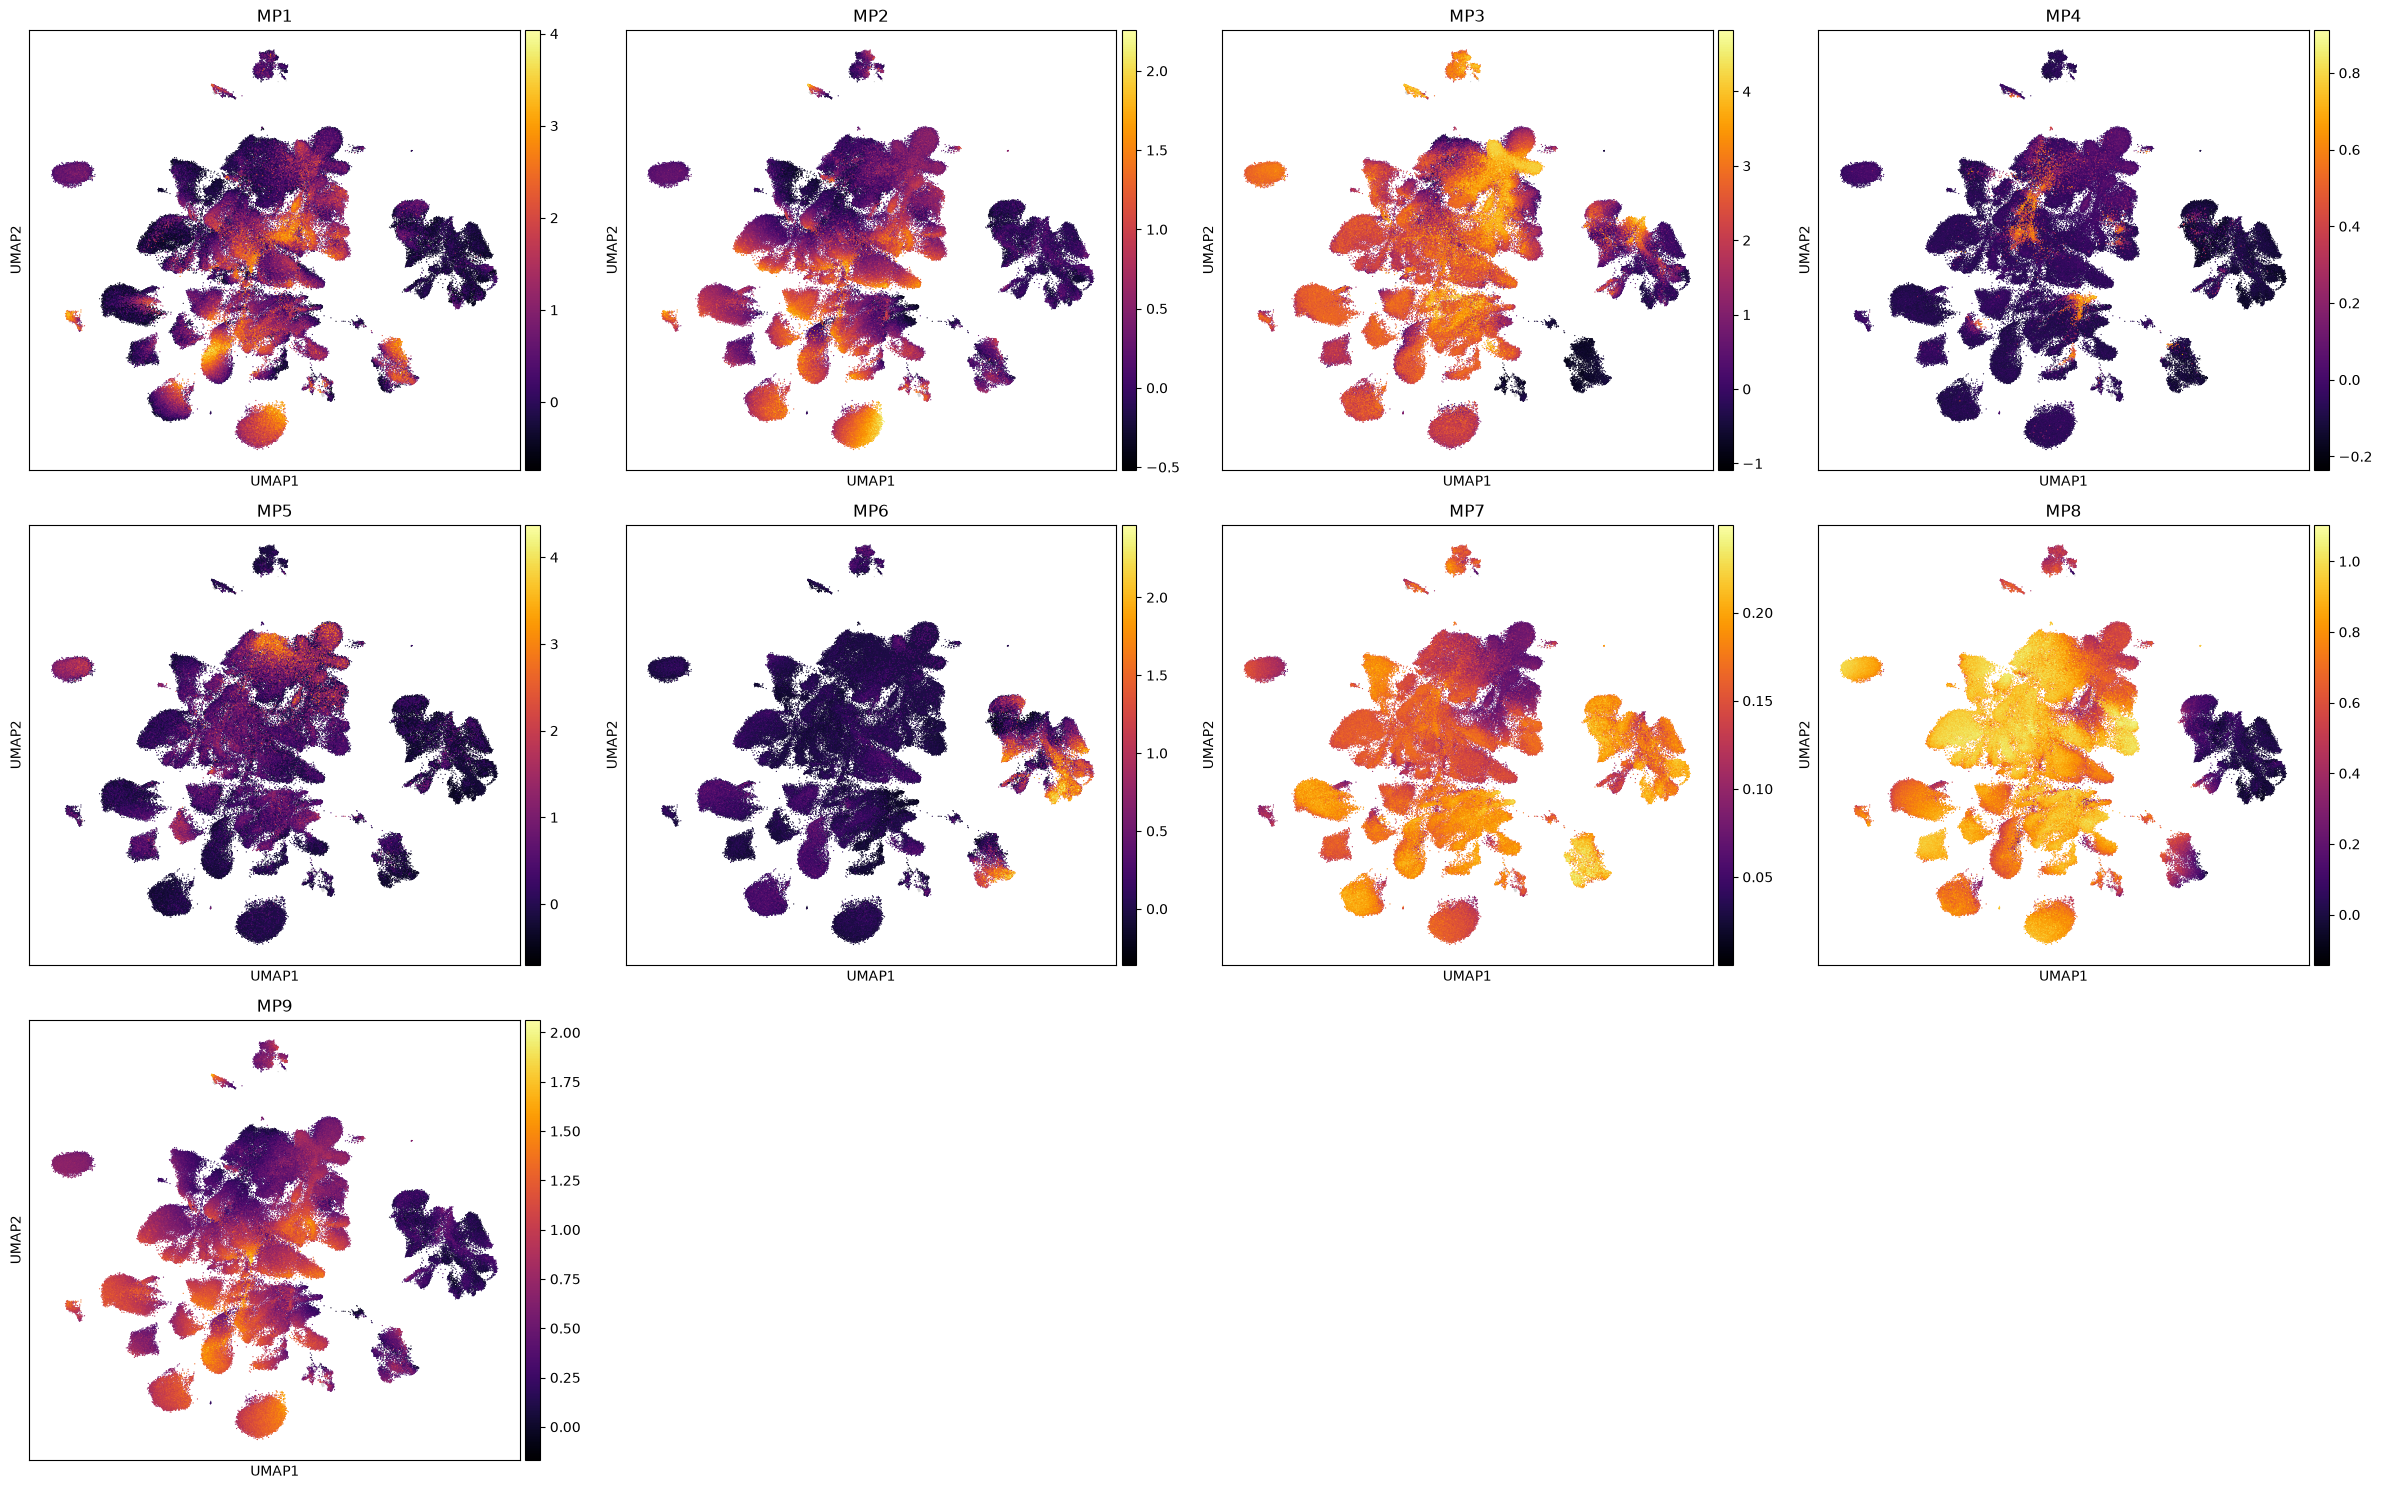

[2026-09-03 15:49:06] PDF saved
[2026-09-03 15:49:06] ALL DONE!


In [77]:
n_cols = 4
n_rows = -(-len(ALL_MPS) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col_name in enumerate(ALL_MPS):
    mp_title = col_name.replace("_score", "")
    if col_name in adata_tam_mg.obs.columns:
        sc.pl.umap(adata_tam_mg, color=col_name, color_map="inferno", ax=axes[i], title=mp_title, size=3, frameon=True, show=False)
        axes[i].set_rasterized(True)
        checkpoint(f"Plotted {mp_title}")
    else:
        checkpoint(f"SKIPPED {mp_title} (not in adata_tam_mg.obs)")

# Hide empty subplots
for j in range(len(ALL_MPS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_08_umap_tam_mg_mpscores.pdf"), bbox_inches="tight", dpi=200)
plt.show()
plt.close()
checkpoint("PDF saved")

checkpoint("ALL DONE!")